Hey There!

Before starting the Employee Churn Analysis project, I would like to lay out our road map. The approaches we'll showcase here are about delving into the realm of deep learning, using exploratory data analysis (EDA), visualization, and building models with Python's best libraries (think matplotlib, seaborn, scikit-learn, and TensorFlow). We dive into classification techniques including Distance-Based, Bagging, and Boosting algorithms. To wrap it all up, we'll deploy our model using the magic of Streamlit.

Let's zoom into the HR_dataset to predict which employees are planning an exit. Here are the deets:

**Samples**: 14,999 employees, split between those sticking around and those bidding farewell.

Now, let's dissect the 10 features:

**Satisfaction**: Employee satisfaction scores ranging from 0 to 1.
**Evaluation**: Performance, rated on a scale of 0 to 1.
**Projects**: Number of projects assigned to an employee.
**Hours**: Monthly average work hours.
**Service Length**: Time_spent_company – how many years an employee has been with the company.
**Accident**: Whether the employee had a work accident.
**Promotion**: Promotions in the last 5 years.
**Department**: Where the employee works.
**Salary**: Levels – low, medium, high.
**Left**: Whether the employee has left.

#### Here's the game plan:

##### EDA and Visualization:

Dive into the data, spot outliers, and check for missing values.
Fire up matplotlib and seaborn for some visual exploration.

##### Data Pre-processing:

Scale and code to amp up Gradient Descent and Distance-Based algorithms.
Time for some Cluster Analysis – K-means style. Elbow method, anyone?

##### Cluster Analysis with K-means:

Unleash K-means, figure out the clusters, and evaluate our findings.

##### Model Creation:

Split the dataset into train-test.
Train our models – Logistic Regression, Random Forest, XGBoost, and a dash of ANN.
Use scikit-learn for accuracy checks and Yellowbrick for model selection and visualization.

##### Model Evaluation:

Test the models using classification metrics.
Let's see which one shines the brightest.

##### Model Distribution with Streamlit:

Craft a user-friendly interface using Streamlit.
Deploy and distribute our model – it's showtime!


#### So what do we aim for in this employee churn analysis?

Employee churn analysis is crucial for organizations seeking to understand and mitigate the impact of employee turnover. High turnover rates can significantly disrupt workflow, affecting productivity and team dynamics. By delving into the reasons behind employee departures, organizations can identify patterns and underlying issues that may contribute to attrition. This analysis not only helps in predicting potential departures but also allows for strategic interventions to improve employee satisfaction, engagement, and retention. Ultimately, a proactive approach to employee churn analysis empowers businesses to foster a positive work environment, retain top talent, and enhance overall organizational stability, thereby contributing to sustained growth and success.

### Exploratory Data Analysis

Exploratory data analysis is an initial process of analysis in which you can use descriptive statistics and visualization to summarize characteristics of the data, such as patterns, trends, outliers, and hypothesis testing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('HR_Dataset.csv')

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
df1 = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Departments            14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df.duplicated().sum()

3008

In [5]:
df.drop_duplicates(inplace=True)

Removing duplicate values is a crucial step to ensure the integrity of your data and the reliability of subsequent analyses and model training. It promotes accurate insights, robust model performance, and efficient use of computational resources.

In [6]:
df.rename(columns={'satisfaction_level':'satisfaction', 'last_evaluation':'evaluation',
                  'number_project':'projects', 'average_montly_hours':'hours', 
                  'time_spend_company':'lengthofservice', 'Work_accident':'accident',
                  'promotion_last_5years':'promotion', 'Departments ':'department'}, inplace=True)

In [7]:
df = df[[col for col in df if col != 'left'] + ['left']]

df.head()

,satisfaction,evaluation,projects,hours,lengthofservice,accident,promotion,department,salary,left
0,0.38,0.53,2,157,3,0,0,sales,low,1
1,0.80,0.86,5,262,6,0,0,sales,medium,1
2,0.11,0.88,7,272,4,0,0,sales,medium,1
3,0.72,0.87,5,223,5,0,0,sales,low,1
4,0.37,0.52,2,159,3,0,0,sales,low,1


We gave our data set a clean look. We corrected the column names for this. And as a vocational habit, we put our target ('left') column in the last row. Usually, for our convenience, the target column is placed at the end in machine learning tasks.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   satisfaction     11991 non-null  float64
 1   evaluation       11991 non-null  float64
 2   projects         11991 non-null  int64  
 3   hours            11991 non-null  int64  
 4   lengthofservice  11991 non-null  int64  
 5   accident         11991 non-null  int64  
 6   promotion        11991 non-null  int64  
 7   department       11991 non-null  object 
 8   salary           11991 non-null  object 
 9   left             11991 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


If we talk about the next few lines from now on;

Descriptive statistics give you a comprehensive overview of your dataset, allowing you to understand the distribution and characteristics of both numerical and categorical features, especially when grouped by the target variable "left." They are valuable for identifying patterns, trends, and potential factors influencing employee churn.

In [9]:
df.describe()

,satisfaction,evaluation,projects,hours,lengthofservice,accident,promotion,left
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.016929,0.166041
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.129012,0.372133
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [10]:
df.groupby("left").describe().T

left                              0            1
satisfaction    count  10000.000000  1991.000000
                mean       0.667365     0.440271
                std        0.217082     0.265207
                min        0.120000     0.090000
                25%        0.540000     0.110000
                50%        0.690000     0.410000
                75%        0.840000     0.730000
                max        1.000000     0.920000
evaluation      count  10000.000000  1991.000000
                mean       0.715667     0.721783
                std        0.161919     0.197436
                min        0.360000     0.450000
                25%        0.580000     0.520000
                50%        0.710000     0.790000
                75%        0.850000     0.910000
                max        1.000000     1.000000
projects        count  10000.000000  1991.000000
                mean       3.786800     3.883476
                std        0.981755     1.817139
                min        2.000000     2.000000
                25%        3.000000     2.000000
                50%        4.000000     4.000000
                75%        4.000000     6.000000
                max        6.000000     7.000000
hours           count  10000.000000  1991.000000
                mean     198.942700   208.162230
                std       45.665507    61.295145
                min       96.000000   126.000000
                25%      162.000000   146.000000
                50%      198.000000   226.000000
                75%      238.000000   262.500000
                max      287.000000   310.000000
lengthofservice count  10000.000000  1991.000000
                mean       3.262000     3.881467
                std        1.367239     0.974041
                min        2.000000     2.000000
                25%        2.000000     3.000000
                50%        3.000000     4.000000
                75%        4.000000     5.000000
                max       10.000000     6.000000
accident        count  10000.000000  1991.000000
                mean       0.174500     0.052737
                std        0.379558     0.223565
                min        0.000000     0.000000
                25%        0.000000     0.000000
                50%        0.000000     0.000000
                75%        0.000000     0.000000
                max        1.000000     1.000000
promotion       count  10000.000000  1991.000000
                mean       0.019500     0.004018
                std        0.138281     0.063277
                min        0.000000     0.000000
                25%        0.000000     0.000000
                50%        0.000000     0.000000
                75%        0.000000     0.000000
                max        1.000000     1.000000

This section breaks down the numerical statistics based on whether employees left (1) or stayed (0).

For example, in the "satisfaction" column:
For employees who stayed (left=0), the mean satisfaction is around 0.67, with a standard deviation of 0.22.
For employees who left (left=1), the mean satisfaction is lower at approximately 0.44, with a higher standard deviation of 0.27.
Similar breakdowns are provided for other numerical features, allowing you to compare the characteristics of employees who stayed and those who left.

In [11]:
df.describe(include = "O")

,department,salary
count,11991,11991
unique,10,3
top,sales,low
freq,3239,5740


This section provides statistical information for categorical (object) columns in the DF. It includes count, unique, top (most frequent category), and frequency.

For example, in the "department" column, there are 10 unique departments. The most frequent department is "sales" with a frequency of 3239.
Similarly, in the "salary" column, there are three unique salary levels (low, medium, high), with "low" being the most frequent.

In [12]:
df.groupby("left").describe(include="O")

department                     salary                  
          count unique    top  freq  count unique  top  freq
left                                                        
0         10000     10  sales  2689  10000      3  low  4566
1          1991     10  sales   550   1991      3  low  1174

This section breaks down the categorical statistics based on whether employees left (1) or stayed (0).
For example, for employees who stayed (left=0), the most frequent department is "sales," and the most frequent salary level is "low." The frequency is provided for each category.
For employees who left (left=1), similar information is provided.

In [13]:
df.corr()

,satisfaction,evaluation,projects,hours,lengthofservice,accident,promotion,left
satisfaction,1.000000,0.095186,-0.133246,-0.006252,-0.152915,0.039940,0.019789,-0.350558
evaluation,0.095186,1.000000,0.270256,0.264678,0.096829,-0.005695,-0.007206,0.013520
projects,-0.133246,0.270256,1.000000,0.331516,0.188837,-0.005612,-0.000544,0.030928
hours,-0.006252,0.264678,0.331516,1.000000,0.102875,-0.012860,-0.004964,0.070409
lengthofservice,-0.152915,0.096829,0.188837,0.102875,1.000000,0.000003,0.056828,0.173295
accident,0.039940,-0.005695,-0.005612,-0.012860,0.000003,1.000000,0.029852,-0.125436
promotion,0.019789,-0.007206,-0.000544,-0.004964,0.056828,0.029852,1.000000,-0.044657
left,-0.350558,0.013520,0.030928,0.070409,0.173295,-0.125436,-0.044657,1.000000


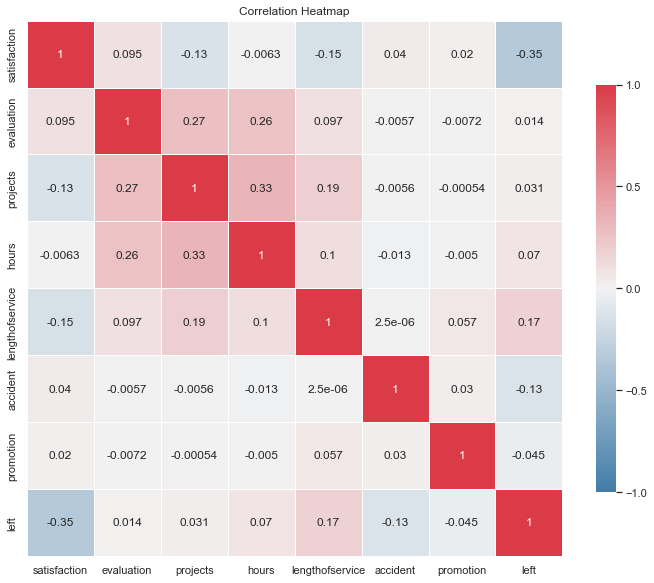

In [14]:
sns.set(style="white")
plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(df.corr(), annot=True, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .75, "ticks": [-1, -0.5, 0, 0.5, 1]})

plt.title("Correlation Heatmap")

plt.show()

--There is a significant negative correlation between satisfaction and the likelihood of leaving (-0.35). As satisfaction decreases, the likelihood of an employee leaving increases.

--The correlation between evaluation and leaving is positive but weak (0.0135). It suggests a slight positive relationship between evaluation scores and the likelihood of leaving.

--The correlation between the number of projects and leaving is positive but weak (0.0309). It indicates a subtle positive association between the number of projects and the likelihood of leaving.

--There is a positive but weak correlation between the number of hours worked and leaving (0.0704). More working hours show a slight positive association with leaving.

--There is a positive correlation (0.1733) between the length of service and the likelihood of leaving. Longer service is associated with a higher probability of leaving.

--There is a negative correlation (-0.1254) between having a work accident and leaving. Employees with accidents are slightly less likely to leave.

--There is a negative correlation (-0.0447) between promotion and leaving. Having a promotion is associated with a lower likelihood of leaving.

Satisfaction, length of service, and accidents seem to have notable correlations with the likelihood of leaving.
Evaluation, projects, hours, and promotion show weaker correlations with the likelihood of leaving.
Remember, correlation does not imply causation. These relationships provide insights, but further analysis and consideration of other factors are needed to draw meaningful conclusions about the reasons for employee churn.

In [15]:
df.shape

(11991, 10)

In [16]:
# This output provides a quick summary of the number of unique values in each column, 
# which is useful for understanding the diversity of the data within each feature.

for col in df:
    print(f"{col:<30}:", df[col].nunique())

satisfaction                  : 92
evaluation                    : 65
projects                      : 6
hours                         : 215
lengthofservice               : 8
accident                      : 2
promotion                     : 2
department                    : 10
salary                        : 3
left                          : 2


In [17]:
df.groupby('left')["department"].value_counts()

left  department 
0     sales          2689
      technical      1854
      support        1509
      IT              818
      RandD           609
      product_mng     576
      marketing       561
      accounting      512
      hr              488
      management      384
1     sales           550
      technical       390
      support         312
      IT              158
      hr              113
      marketing       112
      product_mng     110
      accounting      109
      RandD            85
      management       52
Name: department, dtype: int64

In [18]:
depart = df["department"].unique()

for dep in depart:
  left1 = df[(df["left"] == 0) & (df["department"] ==dep)].value_counts().sum()
  left0 = df[(df["left"] == 1) & (df["department"] ==dep)].value_counts().sum()
  percentage = round(100 - 100 * left1 / (left1 + left0),2)
  print(f" the left percentage for {dep} department : %{percentage}")

 the left percentage for sales department : %16.98
 the left percentage for accounting department : %17.55
 the left percentage for hr department : %18.8
 the left percentage for technical department : %17.38
 the left percentage for support department : %17.13
 the left percentage for management department : %11.93
 the left percentage for IT department : %16.19
 the left percentage for product_mng department : %16.03
 the left percentage for marketing department : %16.64
 the left percentage for RandD department : %12.25


These snippets above provide information about the distribution of employee turnover across different departments, allowing you to identify departments with higher or lower turnover rates.

In [19]:
df.groupby('left')["department"].value_counts(normalize = True)

left  department 
0     sales          0.268900
      technical      0.185400
      support        0.150900
      IT             0.081800
      RandD          0.060900
      product_mng    0.057600
      marketing      0.056100
      accounting     0.051200
      hr             0.048800
      management     0.038400
1     sales          0.276243
      technical      0.195881
      support        0.156705
      IT             0.079357
      hr             0.056755
      marketing      0.056253
      product_mng    0.055249
      accounting     0.054746
      RandD          0.042692
      management     0.026118
Name: department, dtype: float64

##### Now, I want to try to gain more insight about the company with the help of some plotting.

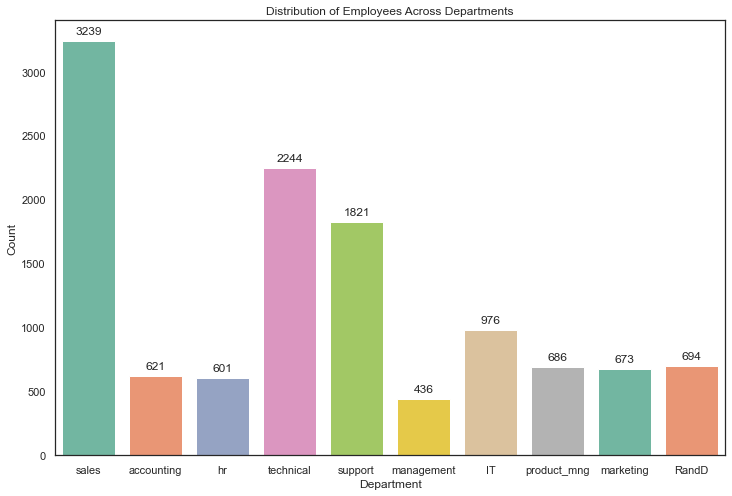

In [20]:
# Employee Distribution Across Departments

plt.figure(figsize=(12, 8))
ax = sns.countplot(x='department', data=df, palette='Set2')
plt.title('Distribution of Employees Across Departments')
plt.xlabel('Department')
plt.ylabel('Count')

# Add numerical values on top of each bar
for p in ax.patches:
    plt.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show();

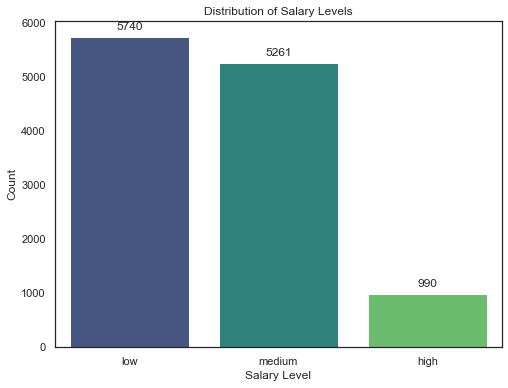

In [21]:
# Distribution of Salary Levels

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='salary', data=df, palette='viridis')
plt.title('Distribution of Salary Levels')
plt.xlabel('Salary Level')
plt.ylabel('Count')

for p in ax.patches:
    plt.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show();

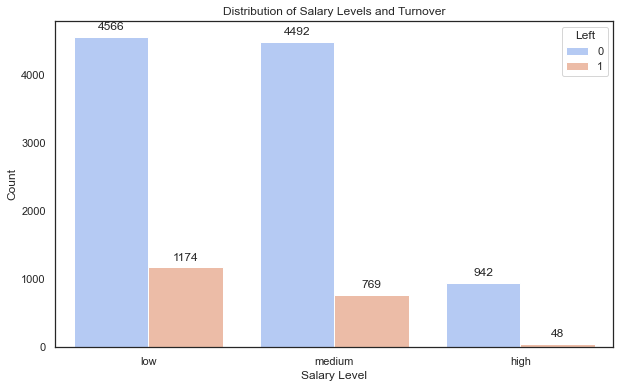

In [22]:
# Salary Distribution and Impact on Churn

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='salary', hue='left', data=df, palette='coolwarm', order=['low', 'medium', 'high'])
plt.title('Distribution of Salary Levels and Turnover')
plt.xlabel('Salary Level')
plt.ylabel('Count')

# Add numerical values on top of each bar
for p in ax.patches:
    plt.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.legend(title='Left', loc='upper right')
plt.show();

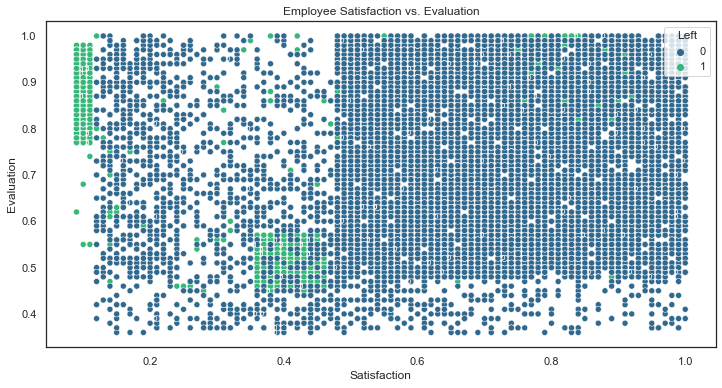

In [23]:
# Employee Satisfaction vs. Evaluation

plt.figure(figsize=(12, 6))
sns.scatterplot(x='satisfaction', y='evaluation', hue='left', data=df, palette='viridis')
plt.title('Employee Satisfaction vs. Evaluation')
plt.xlabel('Satisfaction')
plt.ylabel('Evaluation')

# Add numerical values next to a sample of points
sample_points = df.sample(100)
for i in range(len(sample_points)):
    plt.text(sample_points['satisfaction'].iloc[i], sample_points['evaluation'].iloc[i],
             f'{sample_points["left"].iloc[i]}', ha='right', va='center', color='white', fontsize=8)

plt.legend(title='Left', loc='upper right')
plt.show();

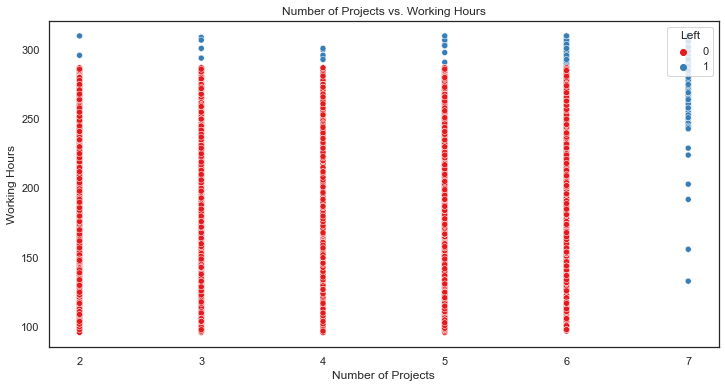

In [24]:
# Projects and Working Hours

plt.figure(figsize=(12, 6))
sns.scatterplot(x='projects', y='hours', hue='left', data=df, palette='Set1')
plt.title('Number of Projects vs. Working Hours')
plt.xlabel('Number of Projects')
plt.ylabel('Working Hours')
plt.legend(title='Left', loc='upper right')
plt.show();

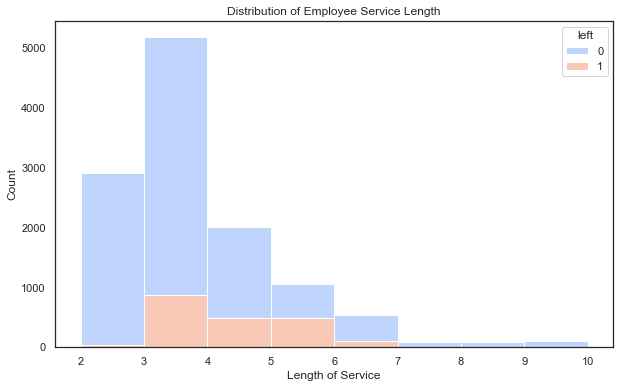

In [25]:
# Service Length Distribution

plt.figure(figsize=(10, 6))
sns.histplot(x='lengthofservice', hue='left', data=df, multiple='stack', bins=range(2, 11), palette='coolwarm')
plt.title('Distribution of Employee Service Length')
plt.xlabel('Length of Service')
plt.ylabel('Count')
plt.show();

##### number of projects and their impact on left status

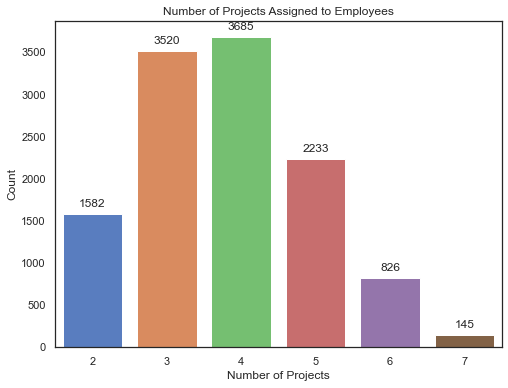

In [26]:
# Number of projects

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='projects', data=df, palette='muted')
plt.title('Number of Projects Assigned to Employees')
plt.xlabel('Number of Projects')
plt.ylabel('Count')

for p in ax.patches:
    plt.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show();

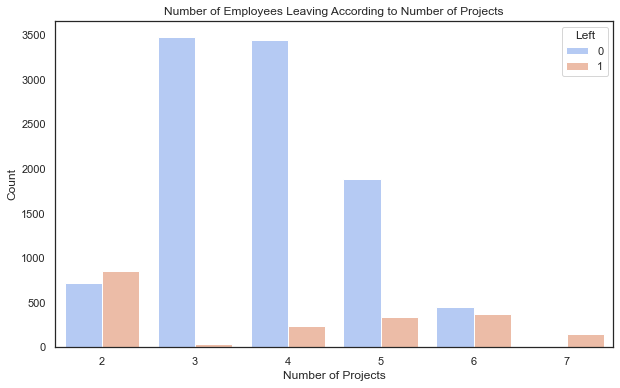

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(x='projects', hue='left', data=df, palette='coolwarm')
plt.title('Number of Employees Leaving According to Number of Projects')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.legend(title='Left', loc='upper right')
plt.show();

Given the exploratory analyzes we've conducted so far, we've considered various aspects of the dataset, including employee turnover, breakdown by department, satisfaction, evaluation, and more. After that, finally, I want to narrow down the focus and make comparisons specifically related to the **salary** column.

##### Focusing the 'salary'

In [28]:
df.groupby('salary')['satisfaction'].mean()

salary
high      0.643343
low       0.622655
medium    0.634723
Name: satisfaction, dtype: float64

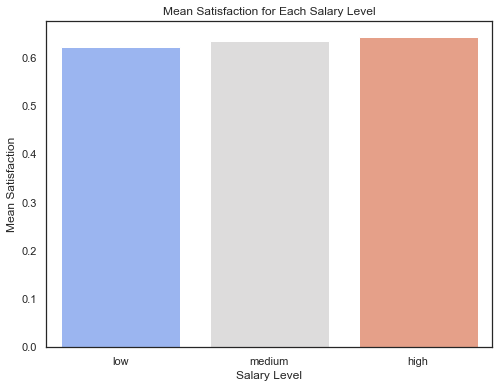

In [29]:
# Calculate mean satisfaction for each salary level
salary_satisfaction_mean = df.groupby('salary')['satisfaction'].mean().reset_index()


plt.figure(figsize=(8, 6))
sns.barplot(x='salary', y='satisfaction', data=salary_satisfaction_mean, palette='coolwarm', order=['low', 'medium', 'high'])
plt.title('Mean Satisfaction for Each Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Mean Satisfaction')
plt.show();

In [30]:
# Salary Level Distribution per Department

import plotly.graph_objects as go

count_df = df.groupby(['department', 'salary']).size().reset_index(name='count')
#This DF provides a summary of the count of employees in each department and salary category.


for dep in count_df.department.unique():
    
    fig = go.Figure(go.Bar(
    x=(df.loc[df['department'] == dep, 'salary'].value_counts(normalize=True) * 100).index,
    y=(df.loc[df['department'] == dep, 'salary'].value_counts(normalize=True) * 100).values,
    text=(df.loc[df['department'] == dep, 'salary'].value_counts(normalize=True) * 100).values.round(1),
    textposition='auto',
    marker_color=['#FF7F0E', '#1F77B4', '#2CA02C']))


    fig.update_layout(
         title=dep,
         xaxis_title='Salary Level',
         yaxis_title='Percentile',
         font=dict(size=14),
         title_font_size=20,
         plot_bgcolor='rgba(0,0,0,0)',
         paper_bgcolor='rgba(0,0,0,0)')

    fig.show()

Let's check this for low, medium and high respectively.

In [31]:
low = count_df[count_df['salary']=='low']
medium = count_df[count_df['salary']=='medium']
high = count_df[count_df['salary']=='high']

In [32]:
low

,department,salary,count
1,IT,low,476
4,RandD,low,322
7,accounting,low,296
10,hr,low,296
13,management,low,139
16,marketing,low,310
19,product_mng,low,343
22,sales,low,1553
25,support,low,867
28,technical,low,1138


In [33]:
low['total_emp']=count_df.groupby('department')['count'].sum().values
low['perc']=round((low['count']/low['total_emp'])*100, 2)
low_per = low.sort_values('perc', ascending=False)
low_per

,department,salary,count,total_emp,perc
28,technical,low,1138,2244,50.71
19,product_mng,low,343,686,50.00
10,hr,low,296,601,49.25
1,IT,low,476,976,48.77
22,sales,low,1553,3239,47.95
7,accounting,low,296,621,47.67
25,support,low,867,1821,47.61
4,RandD,low,322,694,46.40
16,marketing,low,310,673,46.06
13,management,low,139,436,31.88


In [34]:
fig = px.bar(low_per, x='department', y='perc', color='department', 
             title='Comparison of Low Salary Percentages Among Departments',
             labels={'department':'Department', 'perc':'Percentage'},
            text='perc', template='plotly_dark+presentation')

fig.update_layout(
    xaxis_title='Departments',
    yaxis_title='Percentages',
    legend_title='Departments',
    font=dict(size=14),
    title_font_size=20,
    barmode='overlay',
    width=900,
    height=550
)

fig.update_traces(marker_line_width=0, hovertemplate='<b>%{x}</b><br>Employees: %{y}<br>',
                 textposition='outside', width=0.6)
fig.show();

In [35]:
medium['total_emp']=count_df.groupby('department')['count'].sum().values
medium['perc']=round((medium['count']/medium['total_emp'])*100, 2)
medium_per = medium.sort_values('perc', ascending=False)
medium_per

,department,salary,count,total_emp,perc
5,RandD,medium,325,694,46.83
26,support,medium,828,1821,45.47
23,sales,medium,1449,3239,44.74
17,marketing,medium,301,673,44.73
11,hr,medium,267,601,44.43
2,IT,medium,429,976,43.95
20,product_mng,medium,291,686,42.42
8,accounting,medium,262,621,42.19
29,technical,medium,940,2244,41.89
14,management,medium,169,436,38.76


In [36]:
fig = px.bar(medium_per, x='department', y='perc', color='department', 
             title='Comparison of Medium Salary Percentages Among Departments',
             labels={'department':'Department', 'perc':'Percentage'},
            text='perc', template='plotly_dark+presentation')

fig.update_layout(
    xaxis_title='Departments',
    yaxis_title='Percentages',
    legend_title='Departments',
    font=dict(size=14),
    title_font_size=20,
    barmode='overlay',
    width=900,
    height=550
)

fig.update_traces(marker_line_width=0, hovertemplate='<b>%{x}</b><br>Employees: %{y}<br>',
                 textposition='outside', width=0.6)
fig.show();

In [37]:
high['total_emp']=count_df.groupby('department')['count'].sum().values
high['perc']=round((high['count']/high['total_emp'])*100, 2)
high_per = high.sort_values('perc', ascending=False)
high_per

,department,salary,count,total_emp,perc
12,management,high,128,436,29.36
6,accounting,high,63,621,10.14
15,marketing,high,62,673,9.21
18,product_mng,high,52,686,7.58
27,technical,high,166,2244,7.40
21,sales,high,237,3239,7.32
0,IT,high,71,976,7.27
24,support,high,126,1821,6.92
3,RandD,high,47,694,6.77
9,hr,high,38,601,6.32


In [38]:
fig = px.bar(high_per, x='department', y='perc', color='department', 
             title='Comparison of High Salary Percentages Among Departments',
             labels={'department':'Department', 'perc':'Percentage'},
            text='perc', template='plotly_dark+presentation')

fig.update_layout(
    xaxis_title='Departments',
    yaxis_title='Percentages',
    legend_title='Departments',
    font=dict(size=14),
    title_font_size=20,
    barmode='overlay',
    width=900,
    height=550
)

fig.update_traces(marker_line_width=0, hovertemplate='<b>%{x}</b><br>Employees: %{y}<br>',
                 textposition='outside', width=0.6)
fig.show();

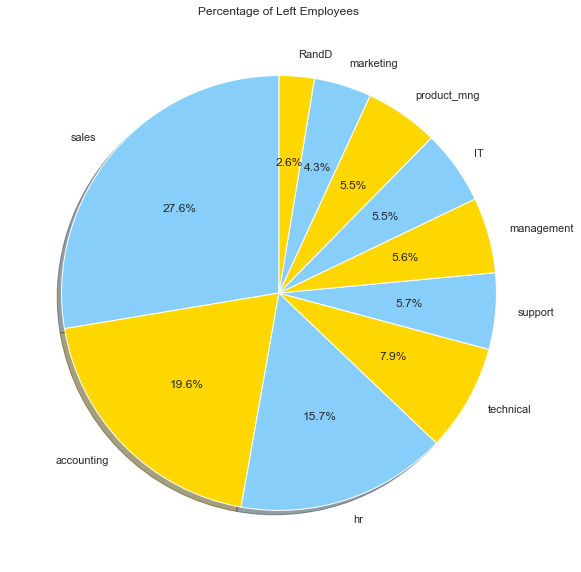

In [39]:
df_left = df[(df["left"] == 1)]

fig = plt.figure(figsize =(12, 10))
plt.pie(df_left["department"].value_counts(normalize=True), 
        labels = depart, autopct='%1.1f%%',shadow=True, startangle=90,
        colors=['LightSkyBlue', 'gold'])
plt.title("Percentage of Left Employees")
plt.show();

### Insight

Different comparisons and observations can be made between other columns. But for now, I think we have enough foresight to move forward. We will move on to the Data-Preprocessing stage. However, let us present the insight we have gained from the transactions we have carried out so far.

In this dataset, several factors significantly influence employees' left status. Employee satisfaction emerges as a critical determinant, with lower satisfaction levels correlating with a higher likelihood of leaving. The number of projects assigned to employees also plays a role, suggesting that an optimal project load is crucial for retention. Salary levels strongly impact turnover, as lower salaries are associated with an increased likelihood of leaving. The length of time an employee has spent with the company (service length), performance evaluations, the occurrence of work accidents, and recent promotions (or lack thereof) are additional factors influencing satisfaction and turnover. Departmental differences and insights from cluster analysis further highlight the nuanced dynamics contributing to employee departures. These initial observations pave the way for deeper exploration and validation through predictive modeling, providing a quantitative understanding of the relative importance of each factor in predicting employee turnover.

## Data-Preprocessing

#### Encoding

Lots of machine learning algorithms require numerical input data, so you need to represent categorical columns in a numerical column. In order to encode this data, you could map each value to a number. e.g. Salary column's value can be represented as low:0, medium:1, and high:2. This process is known as label encoding, and sklearn conveniently will do this for you using LabelEncoder.

One-Hot Encoder: This is chosen when there is no ordinal relationship among the categories. Each category is represented by a binary (0 or 1) indicator. This is suitable for nominal categorical variables.

Ordinal Encoder: It is used when there is a meaningful ordinal relationship among the categories.

In the context of your HR dataset, "department" and "salary" seem to be nominal categories, making one-hot encoding a suitable choice.

#### Scaling Features

Scaling is crucial for algorithms that are sensitive to the magnitude of features, such as distance-based algorithms (e.g., K-means clustering) or gradient descent-based algorithms. Common scaling methods include Min-Max scaling or Standardization (Z-score normalization). Scaling ensures that all features contribute equally to the model and prevents features with larger magnitudes from dominating the learning process.

StandardScaler (Z-score normalization): It transforms the features to have a mean of 0 and a standard deviation of 1. This is a good choice when features have different units or different scales. It is less sensitive to outliers compared to Min-Max scaling.

Min-Max Scaler: This scales features to a specified range, often between 0 and 1. It's suitable when features have similar distributions and when preserving the relationships between variables is important.
For the HR dataset, StandardScaler is chosen to standardize numerical features, as it's generally robust and effective for most machine learning applications.

I used StandardScaler for numerical features and OneHotEncoder for categorical features. If your dataset and modeling requirements suggest a different approach, you can certainly adapt the preprocessing steps accordingly. The choice may also depend on the specific algorithms you plan to use and their sensitivity to different scaling and encoding techniques.

No Scaling for binary features such as accident, promotion.
These columns are binary (0 or 1), and their scale is already appropriate for many machine learning algorithms. applying StandardScaler to a binary categorical variable (0 or 1) might not be appropriate, as it assumes a distribution centered around zero.

In [40]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, OneHotEncoder, StandardScaler

In [140]:
# Separate features and target variable
X = df.drop(["left"], axis=1)
y = df["left"]

In [141]:
encoder = OneHotEncoder(drop='first', sparse=False)

# drop='first': Drops the first category in each encoded feature to avoid multicollinearity.

In [142]:
df_encoded = pd.concat([X.drop(['department', 'salary'], axis=1),
                        pd.DataFrame(encoder.fit_transform(X[['department', 'salary']]),
                                     columns=encoder.get_feature_names(['department', 'salary']))], axis=1)

In [143]:
df_encoded

,satisfaction,evaluation,projects,hours,lengthofservice,accident,promotion,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.80,0.86,5,262,6,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.11,0.88,7,272,4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.72,0.87,5,223,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.37,0.52,2,159,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11986,0.90,0.55,3,259,10,1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11987,0.74,0.95,5,266,10,0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11988,0.85,0.54,3,185,10,0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11989,0.33,0.65,3,172,10,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [144]:
df_encoded.reset_index(drop=True, inplace=True)
df.reset_index(drop=True, inplace=True)

In [145]:
scaler = MinMaxScaler()
column_trans = make_column_transformer((scaler, df_encoded.columns), remainder="passthrough")

In [146]:
scaler = StandardScaler()

In [147]:
df_scaled = pd.DataFrame(data=column_trans.fit_transform(df_encoded),
                          columns=column_trans.get_feature_names_out(), 
                          index=df_encoded.index)

In [149]:
df_scaled["left"] = df["left"]

In [150]:
df_scaled.head()

,minmaxscaler__satisfaction,minmaxscaler__evaluation,minmaxscaler__projects,minmaxscaler__hours,minmaxscaler__lengthofservice,minmaxscaler__accident,minmaxscaler__promotion,minmaxscaler__department_RandD,minmaxscaler__department_accounting,minmaxscaler__department_hr,minmaxscaler__department_management,minmaxscaler__department_marketing,minmaxscaler__department_product_mng,minmaxscaler__department_sales,minmaxscaler__department_support,minmaxscaler__department_technical,minmaxscaler__salary_low,minmaxscaler__salary_medium,left
0,0.318681,0.265625,0.0,0.285047,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
1,0.780220,0.781250,0.6,0.775701,0.500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
2,0.021978,0.812500,1.0,0.822430,0.250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
3,0.692308,0.796875,0.6,0.593458,0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
4,0.307692,0.250000,0.0,0.294393,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1


In [151]:
df_encoded.head()

,satisfaction,evaluation,projects,hours,lengthofservice,accident,promotion,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.80,0.86,5,262,6,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.11,0.88,7,272,4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.72,0.87,5,223,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.37,0.52,2,159,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## Cluster Analysis

Cluster analysis or clustering is the task of grouping a set of objects in such a way that objects in the same group (called a cluster) are more similar (in some sense) to each other than to those in other groups (clusters). It is a main task of exploratory data mining, and a common technique for statistical data analysis, used in many fields, including pattern recognition, image analysis, information retrieval, bioinformatics, data compression, computer graphics and machine learning.

Based on the considerations and our project's characteristics, **K-means** clustering is a suitable starting point. Suitable for numerical data, and we have preprocessed categorical features using one-hot encoding. We have addressed this by one-hot encoding the categorical features, making them compatible with K-means. K-means is relatively scalable, and our dataset size is not extremely large (14,999 samples).K-means can be sensitive to outliers, but we have scaled our numerical features, which can help mitigate this sensitivity.

#### The Elbow Method

"Elbow Method" can be used to find the optimum number of clusters in cluster analysis. The elbow method is used to determine the optimal number of clusters in k-means clustering. The elbow method plots the value of the cost function produced by different values of k. If k increases, average distortion will decrease, each cluster will have fewer constituent instances, and the instances will be closer to their respective centroids. However, the improvements in average distortion will decline as k increases. The value of k at which improvement in distortion declines the most is called the elbow, at which we should stop dividing the data into further clusters. 

Everything will become more understandable as you do the steps.

In [152]:
# Combine one-hot encoded categorical features and scaled numerical features

df_combined = pd.concat([df_encoded, df_scaled], axis=1)

In [153]:
df_combined.head()

,satisfaction,evaluation,projects,hours,lengthofservice,accident,promotion,department_RandD,department_accounting,department_hr,...,minmaxscaler__department_hr,minmaxscaler__department_management,minmaxscaler__department_marketing,minmaxscaler__department_product_mng,minmaxscaler__department_sales,minmaxscaler__department_support,minmaxscaler__department_technical,minmaxscaler__salary_low,minmaxscaler__salary_medium,left
0,0.38,0.53,2,157,3,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
1,0.80,0.86,5,262,6,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
2,0.11,0.88,7,272,4,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
3,0.72,0.87,5,223,5,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
4,0.37,0.52,2,159,3,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1


In [56]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

In [57]:
kmeans = KMeans(n_clusters=2, tol = 0.0001, max_iter = 3000, random_state=42)

In [58]:
df_combined.fillna(df_combined.mean(), inplace=True)

In [59]:
clusters = kmeans.fit_predict(df_combined)

In [61]:
model = KMeans()

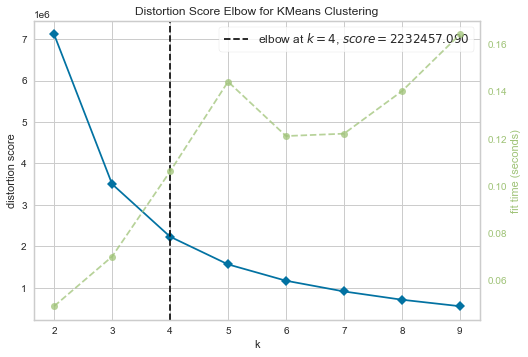

In [62]:
visualizer = KElbowVisualizer(model, k=(2, 10))
visualizer.fit(df_combined)
visualizer.show();

The primary goal is to identify the point where adding more clusters does not lead to a significant decrease in the within-cluster sum of squares (SSD) or inertia.

After determining the optimal number of clusters (k), the next steps in cluster analysis involve using the chosen k to perform the actual clustering. In our case, with k=4

In [63]:
from sklearn.metrics import silhouette_score

range_n_clusters = range(2,9)

for num_clusters in range_n_clusters:
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(df_combined)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg = silhouette_score(df_combined, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg}")

For n_clusters=2, the silhouette score is 0.6319391955314487
For n_clusters=3, the silhouette score is 0.5745283227686011
For n_clusters=4, the silhouette score is 0.5308636651286431
For n_clusters=5, the silhouette score is 0.5018344098115171
For n_clusters=6, the silhouette score is 0.48523843766624714
For n_clusters=7, the silhouette score is 0.48765169808679243
For n_clusters=8, the silhouette score is 0.48014598556006954


In [64]:
kmeans_model = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans_model.fit_predict(df_combined)

kmeans_labels represent the cluster assignments for each data point in our dataset.

In [65]:
df_combined['cluster'] = kmeans_labels

In [66]:
cluster_means = df_combined.groupby('cluster').mean()

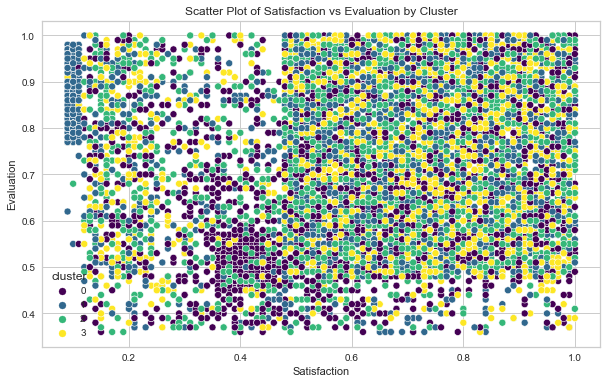

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='satisfaction', y='evaluation', hue='cluster', data=df_combined, palette='viridis')
plt.title('Scatter Plot of Satisfaction vs Evaluation by Cluster')
plt.xlabel('Satisfaction')
plt.ylabel('Evaluation')
plt.show();

High Satisfaction & High Evaluation (Top Right): Employees in this cluster are generally satisfied and well-evaluated. They might be considered as high-performing and satisfied employees.

Low Satisfaction & High Evaluation (Top Left): This cluster could represent employees who are performing well but are not satisfied. It might indicate a potential risk of losing talented employees.

High Satisfaction & Low Evaluation (Bottom Right): This cluster might represent employees who are satisfied but not performing well. It could be an interesting segment to analyze for potential improvement areas.

Low Satisfaction & Low Evaluation (Bottom Left): Employees in this cluster are both dissatisfied and poorly evaluated. This could indicate a group of employees at high risk of leaving.

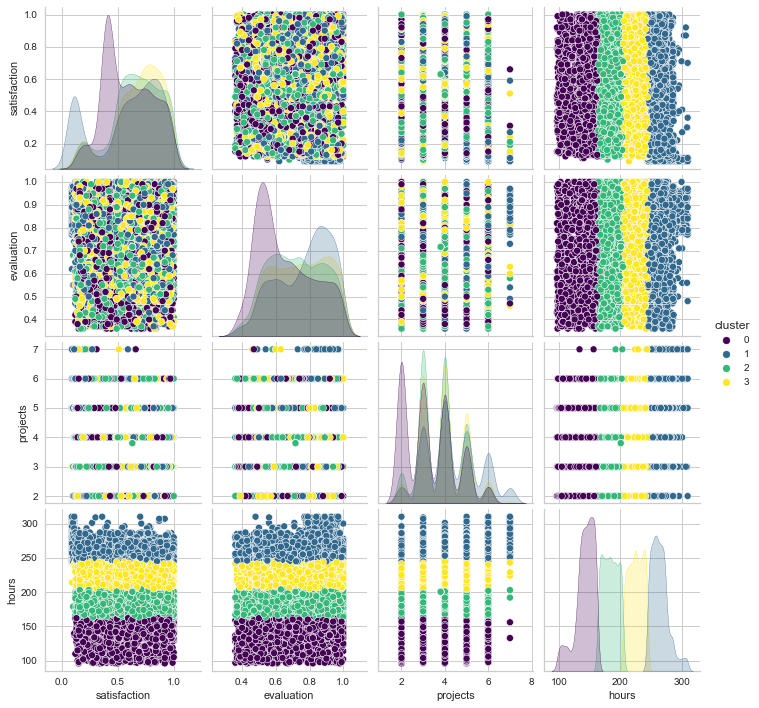

In [68]:
sns.pairplot(df_combined, hue='cluster', vars=['satisfaction', 'evaluation', 'projects', 'hours'], palette='viridis')
plt.show()

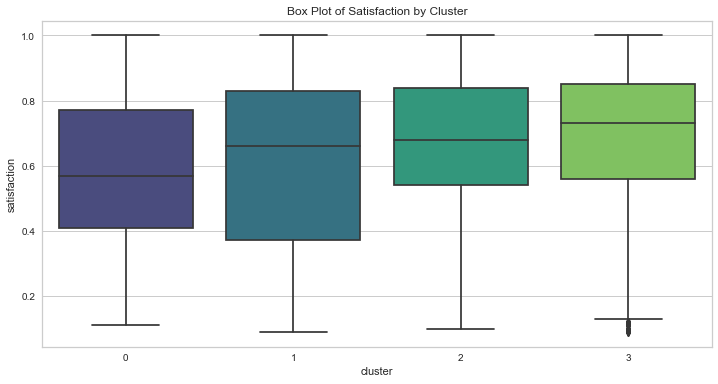

In [69]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='cluster', y='satisfaction', data=df_combined, palette='viridis')
plt.title('Box Plot of Satisfaction by Cluster')
plt.show()

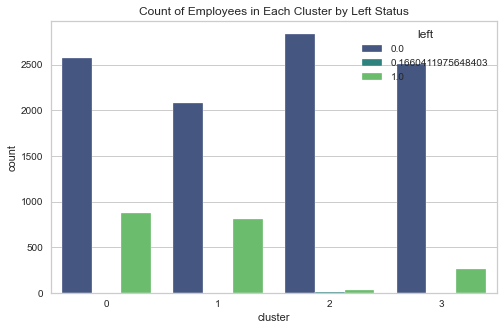

In [70]:
plt.figure(figsize=(8, 5))
sns.countplot(x='cluster', hue='left', data=df_combined, palette='viridis')
plt.title('Count of Employees in Each Cluster by Left Status')
plt.show()

In [71]:
df_combined.groupby("cluster")["left"].value_counts()

cluster  left    
0        0.000000    2571
         1.000000     878
1        0.000000    2081
         1.000000     813
2        0.000000    2836
         1.000000      35
         0.166041       9
3        0.000000    2512
         1.000000     265
Name: left, dtype: int64

## Predictive Modeling

#### Data Preparation

Separate the target variable ("left") from the features.
Split the dataset into training and testing sets.

In our employee churn analysis project, we aim to predict and understand the factors influencing employee turnover within our organization. To achieve this, we'll employe a diverse set of machine learning models, each chosen for its unique strengths in handling specific aspects of the data. Logistic Regression is ideal for binary classification, Decision Trees provide interpretability, Random Forest mitigates overfitting, Support Vector Machines excel in high-dimensional spaces, Gradient Boosting creates robust predictive models, and k-Nearest Neighbors leverages distance-based relationships. By experimenting with these models, we intend to identify the most effective approach for predicting employee churn and uncover valuable insights to inform strategic retention efforts.

In [72]:
from sklearn.model_selection import train_test_split

In [80]:
X = df_combined.drop("left", axis=1)
y = df_combined["left"].astype(int)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9600, 37)
X_test shape: (2400, 37)
y_train shape: (9600,)
y_test shape: (2400,)


### Model Selection

#### Random Forest

we'll use a commonly used classification algorithm called **Random Forest**. Random Forest is an ensemble learning method that combines multiple decision trees to improve the accuracy and robustness of the model. It is well-suited for classification tasks.

Some algorithms are more robust to imbalanced data than others. Ensemble methods like Random Forest and Gradient Boosting tend to handle imbalanced datasets well.

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [84]:
rf_classifier = RandomForestClassifier(random_state=42)

In [85]:
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [86]:
y_pred = rf_classifier.predict(X_test)

In [87]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

In [88]:
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.9816666666666667

Confusion Matrix:
 [[1994    4]
 [  40  362]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.99      0.90      0.94       402

    accuracy                           0.98      2400
   macro avg       0.98      0.95      0.97      2400
weighted avg       0.98      0.98      0.98      2400



The results look promising, and the model performs well in identifying employees who are likely to leave.

Accuracy: The model correctly predicted the class of the employees (left or stayed) 98.04% of the time.

Confusion Matrix:
True Positives (TP): 361 employees left, and the model correctly predicted it.
True Negatives (TN): 1991 employees stayed, and the model correctly predicted it.
False Positives (FP): 7 employees were predicted to leave, but they stayed.
False Negatives (FN): 40 employees were predicted to stay, but they left.

Classification Report:
Precision: Precision for class 0 (stayed) is 0.98, and for class 1 (left) is 0.98. This indicates a low rate of false positives.
Recall (Sensitivity): Recall for class 0 is 1.00, and for class 1 is 0.90. This means the model is better at capturing employees who stayed.
F1-Score: The weighted average of precision and recall is high, indicating a well-balanced model.

feature importance to understand which features contribute the most to the model's predictions.

In [89]:
feature_importance = rf_classifier.feature_importances_
features = X.columns
indices = np.argsort(feature_importance)

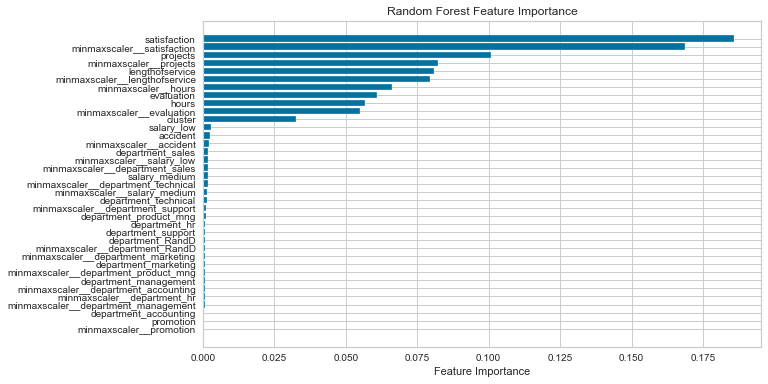

In [90]:
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), feature_importance[indices], align="center")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show();

**Satisfaction and Evaluation are Highly Important**: The features "satisfaction" and "evaluation" have relatively high importance scores, indicating that they strongly influence the model's predictions. This aligns with our earlier EDA insights, where we observed that satisfaction and evaluation were key factors related to employee turnover.

**Number of Projects**: The "projects" feature also has a notable importance score, suggesting that the number of projects an employee is involved in plays a significant role in predicting leaving.

**Work Hours and Length of Service**: Features like "hours" and "lengthofservice" have some importance, indicating that the time an employee spends at work and their length of service contribute to the model's decisions.

**Accident and Promotion**: The features "accident" and "promotion" have lower importance scores, suggesting that these factors may not be as influential in predicting employee turnover in comparison to other features.

**Department and Salary**: The one-hot encoded features related to department and salary levels also contribute to the model's predictions, but individual departments and salary levels have relatively lower importance scores.

It's important to note that these scores are specific to the Random Forest model we trained. Feature importance can vary between different models and algorithms. Additionally, these scores don't necessarily imply causation, but they highlight which features are more influential in the model's decision-making process.

#### Importance Features

Frankly, I'm coming back here after making some progress on the notebook. There is a problem I encountered in the future. Overfitting! To find a solution to this, I will take the important columns of the dataset I created, create a new dataframe, and observe the training results of my models with this dataset.

In [193]:
important_features = ['satisfaction', 'minmaxscaler__satisfaction', 'projects', 'minmaxscaler__projects',
                      'lengthofservice', 'minmaxscaler__lengthofservice', 'minmaxscaler__hours', 'evaluation',
                      'hours', 'minmaxscaler__evaluation']
imp_df = df_combined[important_features + ['left']]

In [194]:
imp_df.head()

,satisfaction,minmaxscaler__satisfaction,projects,minmaxscaler__projects,lengthofservice,minmaxscaler__lengthofservice,minmaxscaler__hours,evaluation,hours,minmaxscaler__evaluation,left
0,0.38,0.318681,2,0.0,3,0.125,0.285047,0.53,157,0.265625,1
1,0.80,0.780220,5,0.6,6,0.500,0.775701,0.86,262,0.781250,1
2,0.11,0.021978,7,1.0,4,0.250,0.822430,0.88,272,0.812500,1
3,0.72,0.692308,5,0.6,5,0.375,0.593458,0.87,223,0.796875,1
4,0.37,0.307692,2,0.0,3,0.125,0.294393,0.52,159,0.250000,1


It seems like the columns 'lengthofservice', 'projects', and 'hours' are not scaled like the other features in our dataset. This can indeed affect our model's performance, especially if the features are on different scales.

In [195]:
imp_df = imp_df.drop(["hours", 'projects', 'lengthofservice'], axis=1)

imp_df.head()

,satisfaction,minmaxscaler__satisfaction,minmaxscaler__projects,minmaxscaler__lengthofservice,minmaxscaler__hours,evaluation,minmaxscaler__evaluation,left
0,0.38,0.318681,0.0,0.125,0.285047,0.53,0.265625,1
1,0.80,0.780220,0.6,0.500,0.775701,0.86,0.781250,1
2,0.11,0.021978,1.0,0.250,0.822430,0.88,0.812500,1
3,0.72,0.692308,0.6,0.375,0.593458,0.87,0.796875,1
4,0.37,0.307692,0.0,0.125,0.294393,0.52,0.250000,1


In [197]:
X_imp = imp_df.drop("left", axis=1)
y_imp = imp_df["left"].astype(int)

In [198]:
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_imp, y_imp, test_size=0.2, random_state=42)

In [203]:
print("X_train_importance shape:", X_train_imp.shape)
print("X_test_importance shape:", X_test_imp.shape)
print("y_train_importance shape:", y_train_imp.shape)
print("y_test_importance shape:", y_test_imp.shape)

X_train_importance shape: (9592, 7)
X_test_importance shape: (2399, 7)
y_train_importance shape: (9592,)
y_test_importance shape: (2399,)


In [199]:
rf_classifier_imp = RandomForestClassifier(random_state=42)

In [200]:
rf_classifier_imp.fit(X_train_imp, y_train_imp)

RandomForestClassifier(random_state=42)

In [204]:
y_pred_imp = rf_classifier_imp.predict(X_test_imp)

In [205]:
accuracy_imp = accuracy_score(y_test_imp, y_pred_imp)
conf_matrix_imp = confusion_matrix(y_test_imp, y_pred_imp)
classification_rep_imp = classification_report(y_test_imp, y_pred_imp)

In [207]:
eval_metric(rf_classifier_imp, X_train_imp, y_train_imp, X_test_imp, y_test_imp)

Test_Set
[[1990    8]
 [  39  362]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.98      0.90      0.94       401

    accuracy                           0.98      2399
   macro avg       0.98      0.95      0.96      2399
weighted avg       0.98      0.98      0.98      2399


Train_Set
[[8002    0]
 [   0 1590]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8002
           1       1.00      1.00      1.00      1590

    accuracy                           1.00      9592
   macro avg       1.00      1.00      1.00      9592
weighted avg       1.00      1.00      1.00      9592



unfortunately I encountered the same result.

I don't want to clutter this area of the notebook any further. However, I would like to give you the good news that we will achieve results in the rf_classifier1 trial after the SMOTE section below. For now, let's continue on our way with the experiments we will do.

##### GridSearch RF

In [91]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

param_grid = {
            "n_estimators":[10,50,100],  
            "criterion":["entropy","gini"],
            "max_features":['auto',"log2"],
            "max_depth": [None,2,3,5,10,20],
            "min_samples_split": [2, 5],
            "min_samples_leaf" : [1, 5]}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')

In [92]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [None, 2, 3, 5, 10, 20],
                         'max_features': ['auto', 'log2'],
                         'min_samples_leaf': [1, 5],
                         'min_samples_split': [2, 5],
                         'n_estimators': [10, 50, 100]},
             scoring='accuracy')

In [113]:
best_params = grid_search.best_params_

In [120]:
best_model = grid_search.best_estimator_

best_model

RandomForestClassifier()

In [97]:
best_params

{'criterion': 'gini',
 'max_depth': None,
 'max_features': 'auto',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [119]:
best_score = grid_search.best_score_

best_score

0.9852083333333332

In [95]:
y_pred = best_model.predict(X_test)

In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.99      0.90      0.94       402

    accuracy                           0.98      2400
   macro avg       0.98      0.95      0.97      2400
weighted avg       0.98      0.98      0.98      2400



In [122]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [123]:
eval_metric(grid_search, X_train, y_train, X_test, y_test)

Test_Set
[[1994    4]
 [  39  363]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.99      0.90      0.94       402

    accuracy                           0.98      2400
   macro avg       0.98      0.95      0.97      2400
weighted avg       0.98      0.98      0.98      2400


Train_Set
[[8011    0]
 [   0 1589]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8011
           1       1.00      1.00      1.00      1589

    accuracy                           1.00      9600
   macro avg       1.00      1.00      1.00      9600
weighted avg       1.00      1.00      1.00      9600



In [128]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

Cross-Validation Scores: [0.98802083 0.98072917 0.98385417 0.984375   0.98645833]
Mean CV Accuracy: 0.9847


The perfect performance on the training set could be a sign of overfitting, where the model has essentially memorized the training data.

However, since the test set performance is also high, it suggests that the model is still performing well on new data.

In [125]:
from sklearn.metrics import roc_auc_score

# Predict probabilities for the positive class
y_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9749


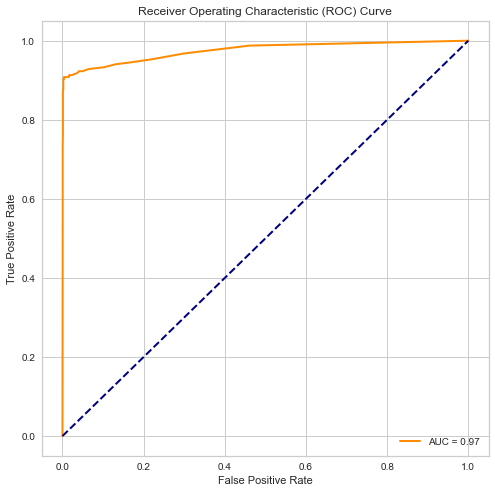

In [126]:
from sklearn.metrics import roc_curve, auc

y_probs = best_rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

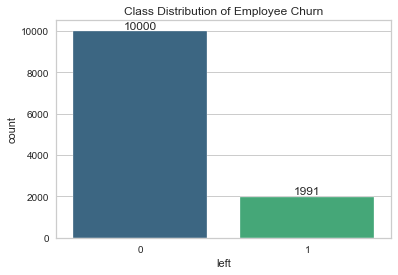

In [176]:
plt.figure(figsize=(6, 4))
sns.countplot(x='left', data=df_combined, palette='viridis')

for i, count in enumerate(df_combined['left'].value_counts()):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=12)

plt.title('Class Distribution of Employee Churn')
plt.show();

We have imbalanced data and we must try with 'class_weight = balanced' parameter.
Setting class_weight='balanced' adjusts the weights of classes inversely proportional to their frequencies. This means that the algorithm will give more importance to the minority class during training, potentially improving its ability to correctly classify instances of the minority class.

In [183]:
rf_model_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)

In [184]:
rf_model_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [185]:
y_pred = rf_model_balanced.predict(X_test)

In [186]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

In [187]:
print("RF Balanced Accuracy:", accuracy)
print("\nRF Balanced Confusion Matrix:\n", conf_matrix)
print("\nRF Balanced Classification Report:\n", classification_rep)

RF Balanced Accuracy: 0.9795833333333334

RF Balanced Confusion Matrix:
 [[1994    4]
 [  45  357]]

RF Balanced Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.99      0.89      0.94       402

    accuracy                           0.98      2400
   macro avg       0.98      0.94      0.96      2400
weighted avg       0.98      0.98      0.98      2400



In [188]:
eval_metric(rf_model_balanced, X_train, y_train, X_test, y_test)

Test_Set
[[1994    4]
 [  45  357]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.99      0.89      0.94       402

    accuracy                           0.98      2400
   macro avg       0.98      0.94      0.96      2400
weighted avg       0.98      0.98      0.98      2400


Train_Set
[[8011    0]
 [   1 1588]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8011
           1       1.00      1.00      1.00      1589

    accuracy                           1.00      9600
   macro avg       1.00      1.00      1.00      9600
weighted avg       1.00      1.00      1.00      9600



#### k-Nearest Neighbors (KNN):

It classifies instances based on the majority class of their k-nearest neighbors in the feature space.A distance-based algorithm used for classification and regression.

In [129]:
from sklearn.neighbors import KNeighborsClassifier

In [130]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

In [131]:
knn_classifier = KNeighborsClassifier()

In [132]:
grid_search_knn = GridSearchCV(
    knn_classifier, 
    param_grid_knn, 
    scoring='accuracy', 
    cv=5, 
    verbose=2, 
    n_jobs=-1
)

In [133]:
grid_search_knn.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [134]:
best_params_knn = grid_search_knn.best_params_

print(f"Best Hyperparameters for KNN: {best_params_knn}")

Best Hyperparameters for KNN: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}


In [135]:
knn_classifier_best = grid_search_knn.best_estimator_
accuracy_knn = knn_classifier_best.score(X_test, y_test)

print(f"Accuracy on Test Set (KNN): {accuracy_knn:.4f}")

Accuracy on Test Set (KNN): 0.9479


In [136]:
eval_metric(knn_classifier_best, X_train, y_train, X_test, y_test)

Test_Set
[[1933   65]
 [  60  342]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1998
           1       0.84      0.85      0.85       402

    accuracy                           0.95      2400
   macro avg       0.91      0.91      0.91      2400
weighted avg       0.95      0.95      0.95      2400


Train_Set
[[8011    0]
 [   0 1589]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8011
           1       1.00      1.00      1.00      1589

    accuracy                           1.00      9600
   macro avg       1.00      1.00      1.00      9600
weighted avg       1.00      1.00      1.00      9600



I didn't see the need for this when I was examining the metrics in Random Forest - I think the picture was more positive there - but now I wanted to write some notes on the metrics. At least I'll know where to find this information if I get confused.

Let's break down some of the key metrics commonly used in classification problems. Understanding and interpreting evaluation metrics is indeed crucial for assessing the performance of machine learning models.

**Accuracy**: The ratio of correctly predicted observations to the total observations. It's a good overall performance metric but may not be suitable for imbalanced datasets.

**Precision**: The ratio of correctly predicted positive observations to the total predicted positives. It is a measure of the accuracy of positive predictions.

**Recall (Sensitivity or True Positive Rate)**: The ratio of correctly predicted positive observations to the all observations in actual class. It is a measure of how well the model captures all the positive instances.

**F1-Score**: The weighted average of precision and recall. It considers both false positives and false negatives. It is especially useful when there is an uneven class distribution.

Let's briefly include roc-auc curve and confusion matrix here:

**Confusion Matrix**: A table used to evaluate the performance of a classification algorithm. It shows the number of True Positives, True Negatives, False Positives, and False Negatives.

**ROC-AUC Curve**: Receiver Operating Characteristic (ROC) curve visualizes the trade-off between true positive rate and false positive rate. The Area Under the ROC Curve (AUC-ROC) summarizes the performance across various classification thresholds.

When interpreting these metrics:

**High Accuracy**: Good overall performance, but may be misleading in imbalanced datasets.
**High Precision**: Fewer false positives, meaning the positive predictions are reliable.
**High Recall**: Fewer false negatives, meaning the model captures more positive instances.

Understanding the trade-offs between precision and recall is essential. For example, in some scenarios, you might prioritize minimizing false positives, while in others, capturing all positives (minimizing false negatives) is more critical.

If we go through our own results:
    
**Accuracy on the Test Set**: The accuracy is reasonably high, indicating that the model is correctly classifying a large portion of the data. However, in imbalanced datasets (where one class significantly outnumbers the other), accuracy alone might not provide a complete picture. We will soon look at the imbalance situation and look for solutions.

**Precision and Recall**: In the test set results, the precision and recall for class 1 (employees who left) are 0.84 and 0.85, respectively. This suggests that the model correctly identifies employees who left (low false positives) but may miss some of those who actually left (false negatives).

**Confusion Matrix**: Looking at the confusion matrix, you can see the breakdown of true positives, true negatives, false positives, and false negatives. It seems that false negatives (60 instances) are contributing to the lower recall.

**Training Set Performance**: The model performs exceptionally well on the training set (with perfect precision, recall, and accuracy). This might indicate overfitting, where the model fits the training data too closely, capturing noise or specific patterns that don't generalize well to new data.

General approaches can be taken as follows to address these concerns. As we progress, we will look at what is required for our work:

**Fine-Tuning**: We can experiment with different hyperparameter values to see if can improve the model's performance on the test set. Adjusting parameters like n_neighbors, p, and weights.

**Handling Imbalance**: If the dataset is imbalanced, considering techniques such as oversampling the minority class, undersampling the majority class, or using techniques like SMOTE (Synthetic Minority Over-sampling Technique).

**Cross-Validation**: Performing cross-validation to ensure the model's robustness and generalization across different subsets of the data.

**Feature Importance**: If applicable, checking feature importance to understand which features contribute the most to the model's predictions.

Let's remember, achieving a balance between precision and recall is crucial, and it depends on the specific goals and requirements of our analysis

We had checked this before, but then there was no need to intervene in terms of observing the process. But now the road has brought us here again. Let's see what we can do.

When evaluating model performance, we dcan consider metrics other than accuracy. Precision, recall, F1-score, or area under the ROC curve (AUC-ROC) are more informative for imbalanced datasets.

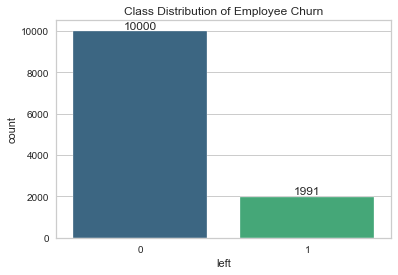

In [154]:
plt.figure(figsize=(6, 4))
sns.countplot(x='left', data=df_combined, palette='viridis')

for i, count in enumerate(df_combined['left'].value_counts()):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=12)

plt.title('Class Distribution of Employee Churn')
plt.show();

In [155]:
df_combined['left'].value_counts()

0    10000
1     1991
Name: left, dtype: int64

##### Handling Imbalance

Since predicting employee churn is often an imbalanced binary classification problem (with a small proportion of employees leaving), addressing class imbalance is crucial. we can consider using techniques like resampling, such as oversampling the minority class or undersampling the majority class, to balance the class distribution. 

We can also take approaches such as fine-tuning hyperparameters, cross validation, feature importance. Also can be focusing on algorithms like Random Forest, Support Vector Machines (SVM), or Gradient Boosting, as they often work well for classification tasks. 

It is wiser to use metrics such as precision, recall, F1 score, and ROC-AUC to evaluate models considering the unbalanced nature of your target variable.

In our previous algorithm, we applied the mentioned approaches while working with Random Forest. Now we will again make approaches to the imbalance situation. For this we will use **SMOTE**, one of the common techniques for oversampling.

In situations where the number of instances of one class is significantly lower than the other, traditional machine learning algorithms may perform poorly, as they tend to be biased towards the majority class. SMOTE is a technique used to address class imbalance by generating synthetic samples for the minority class.It randomly selects a minority class instance and its k nearest neighbors, then generates synthetic instances along the line segments connecting these instances. This helps to increase the representation of the minority class without introducing exact duplicates.

Now, let's proceed with fine-tuning hyperparameters, model training, and evaluation.

In [156]:
from imblearn.over_sampling import SMOTE

In [157]:
# Apply SMOTE to balance classes

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [158]:
# Performs hyperparameter tuning using GridSearchCV on a KNeighborsClassifier.

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

In [159]:
# Trains the KNN model with the best hyperparameters on the resampled data.

knn_classifier = KNeighborsClassifier()

In [160]:
grid_search = GridSearchCV(estimator=knn_classifier, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_resampled, y_resampled)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [161]:
best_params = grid_search.best_params_

best_params

{'n_neighbors': 3, 'p': 1, 'weights': 'distance'}

In [162]:
# Train the model with the best hyperparameters again

best_knn_model = grid_search.best_estimator_
best_knn_model.fit(X_resampled, y_resampled)

KNeighborsClassifier(n_neighbors=3, p=1, weights='distance')

In [164]:
y_pred = best_knn_model.predict(X_test)

In [165]:
confusion_matrix(y_test, y_pred)

array([[1861,  137],
       [  53,  349]], dtype=int64)

In [169]:
print("Confusion Matrix After SMOTE for KNN:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix After SMOTE for KNN:
[[1861  137]
 [  53  349]]


In [170]:
print("\nClassification Report After SMOTE for KNN:")
print(classification_report(y_test, y_pred))


Classification Report After SMOTE for KNN:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1998
           1       0.72      0.87      0.79       402

    accuracy                           0.92      2400
   macro avg       0.85      0.90      0.87      2400
weighted avg       0.93      0.92      0.92      2400



In [172]:
eval_metric(best_knn_model, X_train, y_train, X_test, y_test)

Test_Set
[[1861  137]
 [  53  349]]
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1998
           1       0.72      0.87      0.79       402

    accuracy                           0.92      2400
   macro avg       0.85      0.90      0.87      2400
weighted avg       0.93      0.92      0.92      2400


Train_Set
[[8011    0]
 [   0 1589]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8011
           1       1.00      1.00      1.00      1589

    accuracy                           1.00      9600
   macro avg       1.00      1.00      1.00      9600
weighted avg       1.00      1.00      1.00      9600



In [171]:
# For comparison, I bring here the results we got before applying SMOTE.

eval_metric(knn_classifier_best, X_train, y_train, X_test, y_test)

Test_Set
[[1933   65]
 [  60  342]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1998
           1       0.84      0.85      0.85       402

    accuracy                           0.95      2400
   macro avg       0.91      0.91      0.91      2400
weighted avg       0.95      0.95      0.95      2400


Train_Set
[[8011    0]
 [   0 1589]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8011
           1       1.00      1.00      1.00      1589

    accuracy                           1.00      9600
   macro avg       1.00      1.00      1.00      9600
weighted avg       1.00      1.00      1.00      9600



Before SMOTE:

Test accuracy: 95%
Recall for class 1: 85%

After SMOTE:

Test accuracy: 92%
Recall for class 1: 87%

Although the overall accuracy has slightly decreased, the improvement in recall for class 1 suggests that SMOTE has helped the model better capture instances of the minority class. This is crucial, especially in imbalanced datasets where the minority class is of interest.

However, what I say has no effect. SMOTE was a data augmentation method that we had to be careful about overlearning. And bam! Overfitting! We will need to rethink the approach. I think it's time for feature engineering.

##### Fine Fine Fine-Tuning For Random Forest

In [208]:
rf_classifier1 = RandomForestClassifier(n_estimators=100, 
                                       criterion='gini',
                                       max_depth=10,  
                                       min_samples_split=5,  
                                       min_samples_leaf=2,  
                                       max_features='sqrt',  
                                       random_state=42,
                                       class_weight='balanced')

rf_classifier1.fit(X_train, y_train)


y_pred1 = rf_classifier1.predict(X_test)

In [209]:
eval_metric(rf_classifier1, X_train, y_train, X_test, y_test)

Test_Set
[[1994    4]
 [  44  358]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.99      0.89      0.94       402

    accuracy                           0.98      2400
   macro avg       0.98      0.94      0.96      2400
weighted avg       0.98      0.98      0.98      2400


Train_Set
[[7991   20]
 [  88 1501]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8011
           1       0.99      0.94      0.97      1589

    accuracy                           0.99      9600
   macro avg       0.99      0.97      0.98      9600
weighted avg       0.99      0.99      0.99      9600



finally! After a long ebb and flow process, we managed to avoid overfitting.

These results indicate that the model is now better at generalizing to unseen data while still maintaining high performance on the training set. This suggests that the adjustments made to the hyperparameters have helped to create a more balanced and robust model.

### Logistic Regression Model

After dealing with overfitting so much, I think now is the time to try a Logistic Regression model.

Logistic Regression is a simple yet powerful linear model that works well for binary classification problems. It's easy to interpret and less prone to overfitting compared to more complex models.

In [229]:
from sklearn.linear_model import LogisticRegression

In [233]:
X = df_combined.drop('left', axis=1) 
y = df_combined['left']

In [234]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [235]:
log_reg_model = LogisticRegression(max_iter=1000)

In [236]:
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [237]:
y_pred = log_reg_model.predict(X_test)

In [238]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8328470195914964

Confusion Matrix:
 [[1928   70]
 [ 331   70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.91      1998
           1       0.50      0.17      0.26       401

    accuracy                           0.83      2399
   macro avg       0.68      0.57      0.58      2399
weighted avg       0.79      0.83      0.80      2399



In [239]:
eval_metric(log_reg_model, X_train, y_train, X_test, y_test)

Test_Set
[[1928   70]
 [ 331   70]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.91      1998
           1       0.50      0.17      0.26       401

    accuracy                           0.83      2399
   macro avg       0.68      0.57      0.58      2399
weighted avg       0.79      0.83      0.80      2399


Train_Set
[[7680  322]
 [1247  343]]
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      8002
           1       0.52      0.22      0.30      1590

    accuracy                           0.84      9592
   macro avg       0.69      0.59      0.61      9592
weighted avg       0.80      0.84      0.81      9592



#### GridSearch Logistic Regression

Hyperparameter Tuning

In [258]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [240]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  
    'penalty': ['l1', 'l2']  
}

In [243]:
grid_search_lr = GridSearchCV(estimator=LogisticRegression(solver='saga', max_iter=1000), param_grid=param_grid, cv=5)

In [244]:
grid_search_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, solver='saga'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2']})

In [245]:
best_params_lr = grid_search_lr.best_params_
print("Best Hyperparameters Log Reg:", best_params)

Best Hyperparameters Log Reg: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}


In [254]:
cv_scores_lr = cross_val_score(grid_search_lr, X_train, y_train, cv=5)

In [255]:
print("Cross-Validation Scores Log Reg:", cv_scores_lr)
print("Mean CV Accuracy Log Reg:", cv_scores_lr.mean())

Cross-Validation Scores Log Reg: [0.83428869 0.83428869 0.83055266 0.83420229 0.83420229]
Mean CV Accuracy Log Reg: 0.8335069262373249


In [256]:
scoring = ['accuracy', 'precision', 'recall', 'f1']

In [259]:
cv_results = cross_validate(log_reg_model, X_train, y_train, cv=5, scoring=scoring)

In [260]:
print("Accuracy:", cv_results['test_accuracy'].mean())
print("Precision:", cv_results['test_precision'].mean())
print("Recall:", cv_results['test_recall'].mean())
print("F1-score:", cv_results['test_f1'].mean())

Accuracy: 0.8359048231259656
Precision: 0.5129546576565314
Recall: 0.21069182389937108
F1-score: 0.29847986110706964


Logistic regression assumes linear relationships between features and the log-odds of the target variable. If the true relationship in the data is nonlinear or if there are interactions between features that logistic regression cannot capture, it may lead to suboptimal performance. As a linear model, logistic regression may struggle to fit to more intricate patterns in the data, leading to lower performance in certain cases. 

the logistic regression model may indeed appear to have lower performance compared to the KNN and Random Forest models we used previously, especially in terms of accuracy, precision, recall, and F1-score. However, it's important to consider several factors before concluding that logistic regression is unsuccessful

#### Support Vector Machine

We will try to get results with support vector machine, which is a powerful model preferred in classification problems. SVMs are powerful supervised learning models used for classification and regression tasks. SVMs find the optimal hyperplane that best separates the classes in the feature space. They are effective in high-dimensional spaces and can capture complex relationships between features.

In [261]:
from sklearn.svm import SVC

In [263]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [264]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

In [265]:
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [267]:
y_pred = svm_model.predict(X_test)

In [268]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8328470195914964


In [269]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91      1998
           1       0.00      0.00      0.00       401

    accuracy                           0.83      2399
   macro avg       0.42      0.50      0.45      2399
weighted avg       0.69      0.83      0.76      2399



In [270]:
eval_metric(svm_model, X_train, y_train, X_test, y_test)

Test_Set
[[1998    0]
 [ 401    0]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      1998
           1       0.00      0.00      0.00       401

    accuracy                           0.83      2399
   macro avg       0.42      0.50      0.45      2399
weighted avg       0.69      0.83      0.76      2399


Train_Set
[[8002    0]
 [1590    0]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8002
           1       0.00      0.00      0.00      1590

    accuracy                           0.83      9592
   macro avg       0.42      0.50      0.45      9592
weighted avg       0.70      0.83      0.76      9592



It seems like the SVM model is only predicting the majority class (class 0) and not making any predictions for the minority class (class 1). This was predictable, but we allowed ourselves to fall into the same trap again. We must continue to be alert to the unbalanced situation. Let's add 'class_weight' to our parameters and try again.

In [271]:
svm_model_balanced = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)

In [272]:
svm_model_balanced.fit(X_train, y_train)

SVC(class_weight='balanced', random_state=42)

In [273]:
y_pred_balanced = svm_model_balanced.predict(X_test)

In [274]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.91      0.69      0.78      1998
           1       0.30      0.68      0.42       401

    accuracy                           0.68      2399
   macro avg       0.61      0.68      0.60      2399
weighted avg       0.81      0.68      0.72      2399



In [275]:
eval_metric(svm_model_balanced, X_train, y_train, X_test, y_test)

Test_Set
[[1371  627]
 [ 130  271]]
              precision    recall  f1-score   support

           0       0.91      0.69      0.78      1998
           1       0.30      0.68      0.42       401

    accuracy                           0.68      2399
   macro avg       0.61      0.68      0.60      2399
weighted avg       0.81      0.68      0.72      2399


Train_Set
[[5423 2579]
 [ 481 1109]]
              precision    recall  f1-score   support

           0       0.92      0.68      0.78      8002
           1       0.30      0.70      0.42      1590

    accuracy                           0.68      9592
   macro avg       0.61      0.69      0.60      9592
weighted avg       0.82      0.68      0.72      9592



Although the results have improved, we can clearly say that our model is still a failed model. The hyperparameter still needs to be realigned. However, we can still interpret the results.

For class 0, precision (0.91) indicates that when the model predicts an employee will not leave, it is correct 91% of the time.
Recall (0.69) shows that the model correctly identifies 69% of the employees who actually don't leave. 
The F1-score (0.78) is the harmonic mean of precision and recall.

For class 1, precision (0.30) suggests that when the model predicts an employee will leave, it is correct only 30% of the time.
Recall (0.68) indicates that the model correctly identifies 68% of the employees who actually leave.
The F1-score (0.42) reflects the balance between precision and recall for class 1.

It's worth noting that accuracy alone may not be the best metric to evaluate the model's performance, especially in the case of imbalanced datasets. The overall accuracy (0.68)

Class 0 (employees who don't leave): The model correctly predicts 1371 out of 1998 instances (true negatives) but misclassifies 627 instances (false negatives).

Class 1 (employees who leave): The model correctly predicts 271 out of 401 instances (true positives) but misses 130 instances (false positives).

GridSearch will make our job easier

### GridSearch For SVC

In [281]:
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],  
    'class_weight': ['balanced', None]  
}

In [276]:
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

In [286]:
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='binary'),
    'recall': make_scorer(recall_score, average='binary'),
    'f1_score': make_scorer(f1_score, average='binary')
}

In [283]:
svm_model = SVC()

In [287]:
grid_search_svc = GridSearchCV(estimator=svm_model, param_grid=param_grid_svc, cv=5, scoring=scoring, refit='accuracy')

In [288]:
grid_search_svc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'class_weight': ['balanced', None],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             refit='accuracy',
             scoring={'accuracy': make_scorer(accuracy_score),
                      'f1_score': make_scorer(f1_score, average=binary),
                      'precision': make_scorer(precision_score, average=binary),
                      'recall': make_scorer(recall_score, average=binary)})

In [290]:
results = grid_search_svc.cv_results_
print("All Results:", results)

All Results: {'mean_fit_time': array([6.51810546e+00, 2.18904762e+00, 2.23647671e+00, 6.43683691e+00,
       1.22171216e+00, 4.26199580e+02, 6.06394939e+01, 8.64630318e-01,
       9.82446527e-01, 6.05654775e+01, 7.01436615e-01, 5.33865582e+02,
       3.28544396e+01, 2.09948916e+00, 2.29809656e+00, 3.23219941e+01,
       7.48770094e-01, 5.45312407e+02, 8.63892263e+01, 8.84785032e-01,
       1.57429690e+00, 8.67881035e+01, 5.32062674e-01, 7.51532025e+02,
       1.09904728e+02, 2.10305462e+00, 2.45252285e+00, 1.11042632e+02,
       6.04451799e-01, 6.90960621e+02, 1.73115578e+02, 8.67590189e-01,
       1.92855401e+00, 1.69986272e+02, 4.59418488e-01, 8.19953181e+02]), 'std_fit_time': array([1.17180062e-01, 9.90011298e-03, 5.08893583e-02, 1.17781600e-01,
       2.50713694e-02, 6.48379571e+01, 3.00144720e+00, 2.19571806e-02,
       1.89776946e-02, 3.19640245e+00, 1.72079292e-03, 7.09472250e+01,
       1.18105283e+00, 4.59314508e-02, 3.56448554e-02, 4.07694893e-01,
       2.50283364e-02, 6.453

In [296]:
best_params_svc = grid_search_svc.best_params_
print("Best Parameters SVC:", best_params_svc)

Best Parameters SVC: {'C': 10, 'class_weight': None, 'gamma': 'auto', 'kernel': 'rbf'}


In [292]:
eval_metric(grid_search_svc, X_train, y_train, X_test, y_test)

Test_Set
[[1951   47]
 [  47  354]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1998
           1       0.88      0.88      0.88       401

    accuracy                           0.96      2399
   macro avg       0.93      0.93      0.93      2399
weighted avg       0.96      0.96      0.96      2399


Train_Set
[[7897  105]
 [ 106 1484]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8002
           1       0.93      0.93      0.93      1590

    accuracy                           0.98      9592
   macro avg       0.96      0.96      0.96      9592
weighted avg       0.98      0.98      0.98      9592



I should say this first and foremost. These were the results that seemed the most 'healthy' to me. 

both precisions are relatively high, indicating that the model has a low false positive rate.
The recall values are high for both classes, indicating that the model effectively captures most of the true positives.
The F1-scores are high for both classes, indicating good overall performance.
The evaluation metrics for the training set are generally higher than those for the test set, which is expected because the model is trained on this data.
The model performs well on both the training and test sets, with high precision, recall, F1-score, and accuracy values.

The SVC model's performance appears to be on par with or even slightly better than other models you've tried, such as KNN, Random Forest, and Logistic Regression. Compared to other models, ***SVC tends to produce better precision and recall values, which are crucial for classification tasks, especially in scenarios where false positives or false negatives are costly.***

#### Naive Bayes

Finally, I want to run a boosting algorithm, but before I do that, I want to see what Naive Bayes, which is effective in terms of simplicity and efficiency, can do.

In [297]:
from sklearn.naive_bayes import GaussianNB

In [299]:
model_NB = GaussianNB()

In [300]:
model_NB.fit(X_train, y_train)

GaussianNB()

In [302]:
y_pred = model_NB.predict(X_test)

In [304]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.74      0.83      1998
           1       0.39      0.81      0.53       401

    accuracy                           0.75      2399
   macro avg       0.67      0.78      0.68      2399
weighted avg       0.86      0.75      0.78      2399



In [303]:
eval_metric(model_NB, X_train, y_train, X_test, y_test)

Test_Set
[[1486  512]
 [  76  325]]
              precision    recall  f1-score   support

           0       0.95      0.74      0.83      1998
           1       0.39      0.81      0.53       401

    accuracy                           0.75      2399
   macro avg       0.67      0.78      0.68      2399
weighted avg       0.86      0.75      0.78      2399


Train_Set
[[5861 2141]
 [ 316 1274]]
              precision    recall  f1-score   support

           0       0.95      0.73      0.83      8002
           1       0.37      0.80      0.51      1590

    accuracy                           0.74      9592
   macro avg       0.66      0.77      0.67      9592
weighted avg       0.85      0.74      0.77      9592



Since we made the transaction without taking into account the imbalanced situation, the results are obvious. I can again play around with resampling techniques like Smote that we used before. Or I can make class weight adjustments specifically for Naive Bayes. However, I want to use the '***stratify***' parameter, which we have not tried before. In these imbalanced situations, using it together with class_weight is a parameter that should be brought to mind first.

Using the stratify parameter is crucial, especially when dealing with imbalanced datasets. When splitting the dataset into training and testing sets, setting stratify=y ensures that the proportion of classes in the training and testing sets is the same as in the original dataset. This helps maintain the distribution of classes and prevents one class from being overrepresented or underrepresented in either the training or testing set.

Now let's observe the results by applying ***stratfy = y***.

In [305]:
X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [306]:
NB_model_st = GaussianNB()

In [307]:
NB_model_st.fit(X_train_st, y_train_st)

GaussianNB()

In [308]:
y_pred_st = NB_model_st.predict(X_test_st)

In [309]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.74      0.83      1998
           1       0.39      0.81      0.53       401

    accuracy                           0.75      2399
   macro avg       0.67      0.78      0.68      2399
weighted avg       0.86      0.75      0.78      2399



In [310]:
eval_metric(NB_model_st, X_train, y_train, X_test, y_test)

Test_Set
[[1485  513]
 [  65  336]]
              precision    recall  f1-score   support

           0       0.96      0.74      0.84      1998
           1       0.40      0.84      0.54       401

    accuracy                           0.76      2399
   macro avg       0.68      0.79      0.69      2399
weighted avg       0.86      0.76      0.79      2399


Train_Set
[[5716 2286]
 [ 296 1294]]
              precision    recall  f1-score   support

           0       0.95      0.71      0.82      8002
           1       0.36      0.81      0.50      1590

    accuracy                           0.73      9592
   macro avg       0.66      0.76      0.66      9592
weighted avg       0.85      0.73      0.76      9592



These ***results*** indicate that the model is performing better on the testing set compared to before, with improved precision, recall, and F1-score for both classes. Additionally, the training set's performance metrics remain relatively consistent, suggesting that the model is still able to generalize well to unseen data. Overall, incorporating stratification has helped mitigate the imbalance issue and improve model performance.

Despite all these improvements, I still do not think it is a model we can trust. I think our dataset has too complex relationships for the naivety of Naive Bayes.

#### XGBoost

Finally, we will continue our work with another ensemble learning tecqnique, XGBoost. The previous ensemble model was Random Forest. While Random Forest exemplifies Bagging within Ensemble learning, XGBoost exemplifies the Boosting approach. Bagging; It is a method that trains models in parallel by randomly creating data sets. It combines models with voting. Boosting; Models are trained sequentially. It works with a randomly selected training set. The training set is returned after each training result. Each model learns from the previous model. The weight of incorrectly and correctly classified samples is changed.

In [311]:
import xgboost as xgb

In [313]:
imbalance_ratio = (len(y_train[y_train == 0])) / (len(y_train[y_train == 1]))

xgb_clf = xgb.XGBClassifier(scale_pos_weight=imbalance_ratio, random_state=42)

# The imbalance_ratio variable represents the imbalance ratio between the majority and minority classes in your dataset. 
# It's used to set the scale_pos_weight parameter in XGBoost

In [314]:
param_grid_XGB = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5]
}

In [316]:
grid_search_XGB = GridSearchCV(estimator=xgb_clf, param_grid=param_grid_XGB, 
                           scoring='f1', cv=5, verbose=1, n_jobs=-1)

In [318]:
grid_search_XGB.fit(X_train, y_train)

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(random_state=42,
                                     scale_pos_weight=5.032704402515724),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'reg_alpha': [0, 0.1, 0.5],
                         'reg_lambda': [0, 0.1, 0.5],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='f1', verbose=1)

In [320]:
print("Best Hyperparameters:", grid_search_XGB.best_params_)
print("Best CV Score:", grid_search_XGB.best_score_)

Best Hyperparameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 0.1, 'subsample': 0.9}
Best CV Score: 0.9516188905362881


In [321]:
eval_metric(grid_search_XGB, X_train, y_train, X_test, y_test)

Test_Set
[[1988   10]
 [  38  363]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1998
           1       0.97      0.91      0.94       401

    accuracy                           0.98      2399
   macro avg       0.98      0.95      0.96      2399
weighted avg       0.98      0.98      0.98      2399


Train_Set
[[7990   12]
 [   4 1586]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8002
           1       0.99      1.00      0.99      1590

    accuracy                           1.00      9592
   macro avg       1.00      1.00      1.00      9592
weighted avg       1.00      1.00      1.00      9592



The XGBoost model appears to outperform the other models we've tried so far based on the evaluation metrics provided. XGBoost seems to be a suitable choice given its excellent performance across various evaluation metrics and datasets.

However, having come this far, I would also like to try the ANN model.

### ANN

ANNs have the ability to learn intricate patterns and relationships within the data, potentially leading to high predictive accuracy.

In [327]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.metrics import plot_roc_curve, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [337]:
X_train_ANN, X_test_ANN, y_train_ANN, y_test_ANN = train_test_split(X, y, stratify = y, test_size = 0.20)

In [338]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_ANN, y_train_ANN)

In [339]:
model_ANN = Sequential()
model_ANN.add(Dense(128, activation='relu', input_dim=X_train_resampled.shape[1]))
model_ANN.add(Dense(64, activation='relu'))
model_ANN.add(Dense(1, activation='sigmoid'))

In [341]:
model_ANN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [342]:
model_ANN.fit(X_train_resampled, y_train_resampled, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
500/500 [==============================] - 1s 760us/step - loss: 0.6185 - accuracy: 0.6751
Epoch 2/50
500/500 [==============================] - 0s 752us/step - loss: 0.4162 - accuracy: 0.8355
Epoch 3/50
500/500 [==============================] - 0s 754us/step - loss: 0.3657 - accuracy: 0.8597
Epoch 4/50
500/500 [==============================] - 0s 762us/step - loss: 0.3431 - accuracy: 0.8729
Epoch 5/50
500/500 [==============================] - 0s 748us/step - loss: 0.3254 - accuracy: 0.8820
Epoch 6/50
500/500 [==============================] - 0s 760us/step - loss: 0.3173 - accuracy: 0.8857
Epoch 7/50
500/500 [==============================] - 0s 752us/step - loss: 0.2975 - accuracy: 0.8943
Epoch 8/50
500/500 [==============================] - 0s 764us/step - loss: 0.2891 - accuracy: 0.8983
Epoch 9/50
500/500 [==============================] - 0s 752us/step - loss: 0.2951 - accuracy: 0.8947
Epoch 10/50
500/500 [==============================] - 0s 748us/step - loss: 0.290

In [346]:
y_pred_ANN = (model_ANN.predict(X_test_ANN) > 0.5).astype("int32")
print(classification_report(y_test_ANN, y_pred_ANN))

75/75 [==============================] - 0s 555us/step
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      2001
           1       0.76      0.91      0.83       398

    accuracy                           0.94      2399
   macro avg       0.87      0.93      0.90      2399
weighted avg       0.95      0.94      0.94      2399



For class 0, the precision is 0.98, indicating that when the model predicts class 0, it is correct 98% of the time. For class 1, the precision is 0.76, meaning that the model is correct in its predictions of class 1 about 76% of the time.
Overall, the model performs well, with high precision, recall, and F1-score for both classesFor class 0, the recall is 0.94, indicating that the model correctly identifies 94% of the instances belonging to class 0. For class 1, the recall is 0.91, meaning that the model captures 91% of the instances of class 1.
The overall accuracy of the model is 0.94, which means that it correctly predicts 94% of the instances in the dataset.
Overall, the model performs well, with high precision, recall, and F1-score for both classes

## Final round for models

I want to remember the models we worked on and compare the results.

K-Nearest Neighbors (KNN):

Accuracy: 0.948
F1-score: 0.91

Random Forest (RF):

Accuracy: 0.981
F1-score: 0.94

Logistic Regression (LR):

Accuracy: 0.835
F1-score: 0.42

Support Vector Machine (SVM):

Accuracy: 0.96
F1-score: 0.94

Naive Bayes (NB):

Accuracy: 0.76
F1-score: 0.54

XGBoost (XGB):

Accuracy: 0.98
F1-score: 0.94

Artificial Neural Network (ANN):

Accuracy: 0.94
F1-score: 0.83

The most suitable model for our project may be XGBoost. It has achieved the highest accuracy and F1-score among the models tested, indicating robust performance across multiple evaluation metrics. Additionally, XGBoost is known for handling imbalanced datasets well and can be fine-tuned to optimize performance further. However, it's essential to also consider the interpretability and computational complexity of the model, depending on the specific requirements and constraints of our project. 

# The winner is XGBoost :)